# 0. Imports

In [52]:
import json
from pathlib import Path
    
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np

# 1. Configuration

In [53]:
ROOT = Path('..').resolve()
FIGURES = ROOT / 'data' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

CLOUDS = {
    'aws':   ('eks', sorted((ROOT / 'metrics' / 'aws').glob('*/'))[-1]),
    'azure': ('aks', sorted((ROOT / 'metrics' / 'azure').glob('*/'))[-1]),
    'gcp':   ('gke', sorted((ROOT / 'metrics' / 'gcp').glob('*/'))[-1]),
}

PERF_METRICS = ['testDuration', 'ttfb', 'domInteractive', 'domContentLoaded',
                'loadComplete', 'fcp', 'lcp', 'cls', 'tbt', 'inp']

NAV_METRICS = ['dnsLookup', 'tcpConnect', 'tlsHandshake', 'serverProcessing', 'contentDownload']

plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})
sns.set_theme(style='whitegrid')

## 1.1. Load Raw Performance Data
Walks each cloud's iteration directories and reads the per-iteration JSON result files into a flat list of records. Skips any iteration whose file is missing. Encodes `cloud` and `environment` as ordered categoricals to ensure consistent grouping and plot ordering.

In [54]:
records = []
for cloud, (env, run_dir) in CLOUDS.items():
    for it_dir in sorted(run_dir.glob('iteration-*')):
        jf = it_dir / f'{cloud}_{env}.json'
        if not jf.exists():
            continue
        for r in json.loads(jf.read_text()):
            records.append(r)

df = pd.DataFrame(records)
df['cloud'] = pd.Categorical(df['cloud'], categories=['aws', 'azure', 'gcp'])
df['environment'] = pd.Categorical(df['environment'], categories=['eks', 'aks', 'gke'])

print(f'{len(df):,} test records  |  clouds: {df["cloud"].unique().tolist()}')
df[['cloud', 'environment', 'iteration', 'testName'] + PERF_METRICS].head(10)

551 test records  |  clouds: ['aws', 'azure', 'gcp']


,cloud,environment,iteration,testName,testDuration,ttfb,domInteractive,domContentLoaded,loadComplete,fcp,lcp,cls,tbt,inp
0,aws,eks,1,should add a product to the cart,4887,20.2,52.5,52.5,52.5,80,80,0.000,0,-1
1,aws,eks,1,should clear the cart,1603,79.9,112.9,112.9,113.0,164,164,0.000,0,-1
2,aws,eks,1,should display checkout form,760,14.3,57.9,58.1,58.2,80,80,0.000,0,24
3,aws,eks,1,should complete full purchase,1203,21.0,63.0,64.8,64.9,-1,-1,0.000,0,-1
4,aws,eks,1,should load the home page and display products,282,28.7,151.3,151.6,169.6,156,244,0.215,0,-1
5,aws,eks,1,should navigate to product details page when a...,427,15.8,74.4,74.5,74.6,120,120,0.000,0,-1
6,aws,eks,10,should add a product to the cart,4845,19.8,79.5,79.6,79.6,100,100,0.000,0,-1
7,aws,eks,10,should clear the cart,1334,11.8,39.8,39.9,42.6,140,140,0.000,0,80
8,aws,eks,10,should display checkout form,705,14.9,51.7,54.2,54.3,72,72,0.000,0,-1
9,aws,eks,10,should complete full purchase,16126,13.1,40.3,40.7,42.1,80,80,0.000,0,24


## 1.2. Load Runner Timings & Network RTT
For each iteration, reads `runner_timings.json` (install and test wall-clock seconds) and `network_rtt.json` (five network probes to the application endpoint). Averages the probe results and stores them in `runner_df`. Also replaces the sentinel value -1 in FCP, LCP, and INP with NaN so those missing observations are excluded from statistics.

In [55]:
df[['fcp', 'lcp', 'inp']] = df[['fcp', 'lcp', 'inp']].replace(-1, np.nan)

runner_records = []
for cloud, (env, run_dir) in CLOUDS.items():
    for it_dir in sorted(run_dir.glob('iteration-*')):
        tf = it_dir / 'runner_timings.json'
        rf = it_dir / 'network_rtt.json'
        pf = it_dir / 'provider_timings.json'
        if not tf.exists() or not rf.exists() or not pf.exists():
            continue
        t = json.loads(tf.read_text())
        probes = json.loads(rf.read_text())
        p = json.loads(pf.read_text())
        runner_records.append({
            'cloud': cloud,
            'environment': env,
            'iteration': int(it_dir.name.split('-')[1]),
            'installSeconds': t['installSeconds'],
            'testSeconds': t['testSeconds'],
            'runnerQueueSeconds': p.get('runnerQueueSeconds', np.nan),
            'runnerExecutionSeconds': p.get('runnerExecutionSeconds', np.nan),
            'dns_ms': np.mean([p['dnsSeconds'] for p in probes]) * 1000,
            'tcp_ms': np.mean([p['tcpSeconds'] for p in probes]) * 1000,
            'rtt_ttfb_ms': np.mean([p['ttfbSeconds'] for p in probes]) * 1000,
            'rtt_total_ms': np.mean([p['totalSeconds'] for p in probes]) * 1000,
        })

runner_df = pd.DataFrame(runner_records)
runner_df['cloud'] = pd.Categorical(runner_df['cloud'], categories=['aws', 'azure', 'gcp'])
# -1 sentinel means provider API call failed; treat as missing
runner_df[['runnerQueueSeconds', 'runnerExecutionSeconds']] = (
    runner_df[['runnerQueueSeconds', 'runnerExecutionSeconds']].replace(-1, np.nan)
)
print(f'{len(runner_df)} runner records  |  fcp NaNs: {df["fcp"].isna().sum()}  lcp NaNs: {df["lcp"].isna().sum()}  inp NaNs: {df["inp"].isna().sum()}')
runner_df.groupby('cloud')[['runnerQueueSeconds', 'runnerExecutionSeconds', 'installSeconds', 'testSeconds',
                             'dns_ms', 'tcp_ms', 'rtt_ttfb_ms', 'rtt_total_ms']].mean().round(2)

90 runner records  |  fcp NaNs: 72  lcp NaNs: 76  inp NaNs: 345


,runnerQueueSeconds,runnerExecutionSeconds,installSeconds,testSeconds,dns_ms,tcp_ms,rtt_ttfb_ms,rtt_total_ms
cloud,,,,,,,,
aws,0.57,126.70,44.37,24.83,1.19,2.83,23.50,24.34
azure,8.27,78.07,42.97,13.10,0.02,14.08,44.04,44.40
gcp,1.03,121.60,39.40,21.00,0.02,1.34,16.96,17.20


# 2. Descriptive Statistics
Computes mean, median, standard deviation, and 95th percentile for every performance metric, grouped by cloud and test name. Gives a per-test summary table used as the basis for statistical comparisons.

In [56]:
def p95(x): return np.percentile(x, 95)

desc = (
    df.groupby(['cloud', 'testName'])[PERF_METRICS]
    .agg(['mean', 'median', 'std', p95])
    .round(2)
)
desc

testDuration          \
                                                                 mean  median   
cloud testName                                                                  
aws   should add a product to the cart                        3730.33  4448.5   
      should clear the cart                                   1489.07  1403.5   
      should complete full purchase                           3398.66  1292.0   
      should display checkout form                             865.70   763.0   
      should load the home page and display products           307.93   281.5   
      should navigate to product details page when a ...       480.67   464.0   
azure should add a product to the cart                         771.80   742.0   
      should clear the cart                                   1316.27  1211.0   
      should complete full purchase                           2522.45  1154.0   
      should display checkout form                             766.53   760.5   
      should load the home page and display products           301.60   299.5   
      should navigate to product details page when a ...       474.50   453.5   
gcp   should add a product to the cart                        1092.07  1088.5   
      should clear the cart                                   1953.33  1907.5   
      should complete full purchase                           3221.33  1882.0   
      should display checkout form                            1131.97  1123.0   
      should load the home page and display products           445.70   449.0   
      should navigate to product details page when a ...       695.57   683.0   

                                                                             \
                                                              std       p95   
cloud testName                                                                
aws   should add a product to the cart                    1474.02   4951.45   
      should clear the cart                                240.13   1998.65   
      should complete full purchase                       5284.11  16175.10   
      should display checkout form                         361.41   1048.25   
      should load the home page and display products       122.86    422.90   
      should navigate to product details page when a ...    76.44    635.75   
azure should add a product to the cart                     132.12   1010.45   
      should clear the cart                                243.98   1535.15   
      should complete full purchase                       4379.38  16100.20   
      should display checkout form                          79.17    873.25   
      should load the home page and display products        30.54    345.30   
      should navigate to product details page when a ...    50.57    557.70   
gcp   should add a product to the cart                      73.90   1175.80   
      should clear the cart                                208.10   2343.75   
      should complete full purchase                       4358.49  16726.00   
      should display checkout form                          98.16   1303.00   
      should load the home page and display products        43.21    510.90   
      should navigate to product details page when a ...    55.48    800.40   

                                                           ttfb                \
                                                           mean median    std   
cloud testName                                                                  
aws   should add a product to the cart                    20.62  20.35   1.92   
      should clear the cart                               14.63  12.30  12.36   
      should complete full purchase                       19.55  20.30   3.79   
      should display checkout form                        14.87  14.50   1.31   
      should load the home page and display products      20.35  20.00   2.79   
      should navigate to product details page w

## 2.1. Distribution Box Plots
Visualises the spread and skew of key metrics per cloud. Bars hide outliers and distribution shape; box plots reveal them.

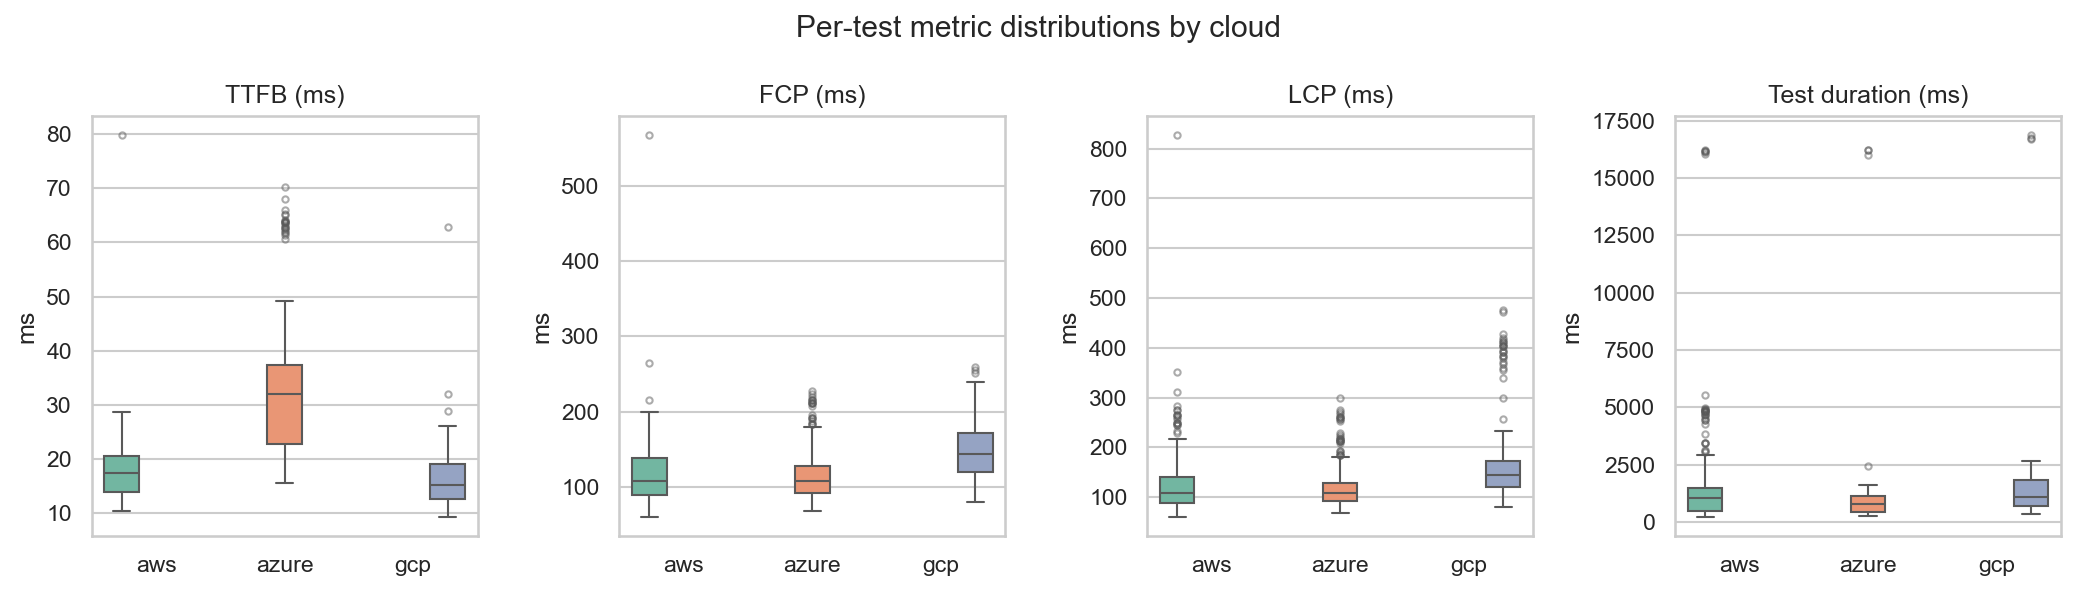

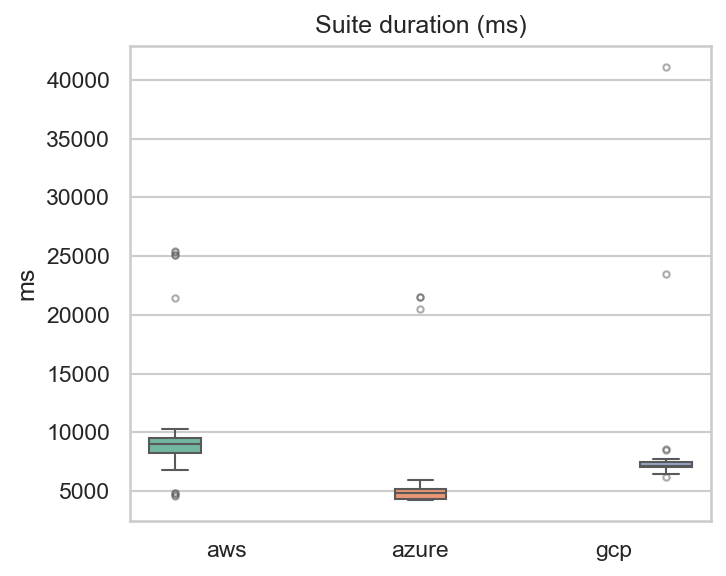

In [57]:
plot_metrics = [
    ('ttfb',         'TTFB (ms)'),
    ('fcp',          'FCP (ms)'),
    ('lcp',          'LCP (ms)'),
    ('testDuration', 'Test duration (ms)'),
]

fig, axes = plt.subplots(1, len(plot_metrics), figsize=(14, 4))
for ax, (col, label) in zip(axes, plot_metrics):
    sns.boxplot(data=df, x='cloud', y=col, hue='cloud',
                legend=False, palette='Set2', ax=ax,
                flierprops=dict(marker='o', markersize=3, alpha=0.5))
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel('ms')

# Suite duration uses the iteration-aggregated dataframe
fig2, ax2 = plt.subplots(figsize=(5, 4))
sns.boxplot(data=suite, x='cloud', y='suiteDuration', hue='cloud',
            legend=False, palette='Set2', ax=ax2,
            flierprops=dict(marker='o', markersize=3, alpha=0.5))
ax2.set_title('Suite duration (ms)')
ax2.set_xlabel('')
ax2.set_ylabel('ms')

fig.suptitle('Per-test metric distributions by cloud')
fig.tight_layout()
fig.savefig(FIGURES / 'metric_boxplots.png', dpi=300)

fig2.tight_layout()
fig2.savefig(FIGURES / 'suite_duration_boxplot.png', dpi=300)
plt.show()

## 2.2. Coefficient of Variation
CV = σ/μ × 100 %. Measures predictability: a lower CV means the cloud produces more consistent results run-to-run, independent of whether its mean is faster or slower.

In [58]:
cv_metrics = [m for m in PERF_METRICS if df[m].std() > 0]

cv_df = (
    df.groupby('cloud')[cv_metrics]
    .agg(lambda x: x.std() / x.mean() * 100 if x.mean() != 0 else np.nan)
    .round(1)
)
cv_df.columns.name = 'CV %'

# Compute suiteDuration CV inline (suite df is defined later in section 3)
suite_cv = (
    df.groupby(['cloud', 'iteration'])['testDuration']
    .sum()
    .groupby('cloud')
    .agg(lambda x: x.std() / x.mean() * 100)
    .round(1)
)
cv_df.insert(0, 'suiteDuration', suite_cv)

cv_df

CV %,suiteDuration,testDuration,ttfb,domInteractive,domContentLoaded,loadComplete,fcp,lcp,cls,inp
cloud,,,,,,,,,,
aws,59.2,155.1,34.2,63.4,63.2,78.5,43.1,61.9,234.5,39.4
azure,78.5,189.6,39.3,50.0,50.0,57.9,34.0,42.7,231.3,27.2
gcp,76.6,142.0,32.6,58.1,57.8,66.2,28.0,53.6,233.0,42.5


# 3. Suite Duration per Iteration
Aggregates per-test durations into a total suite duration for each cloud × iteration combination, then plots it as a time series. Reveals stability and outliers (e.g. flaky-test retries) across the 30 runs.

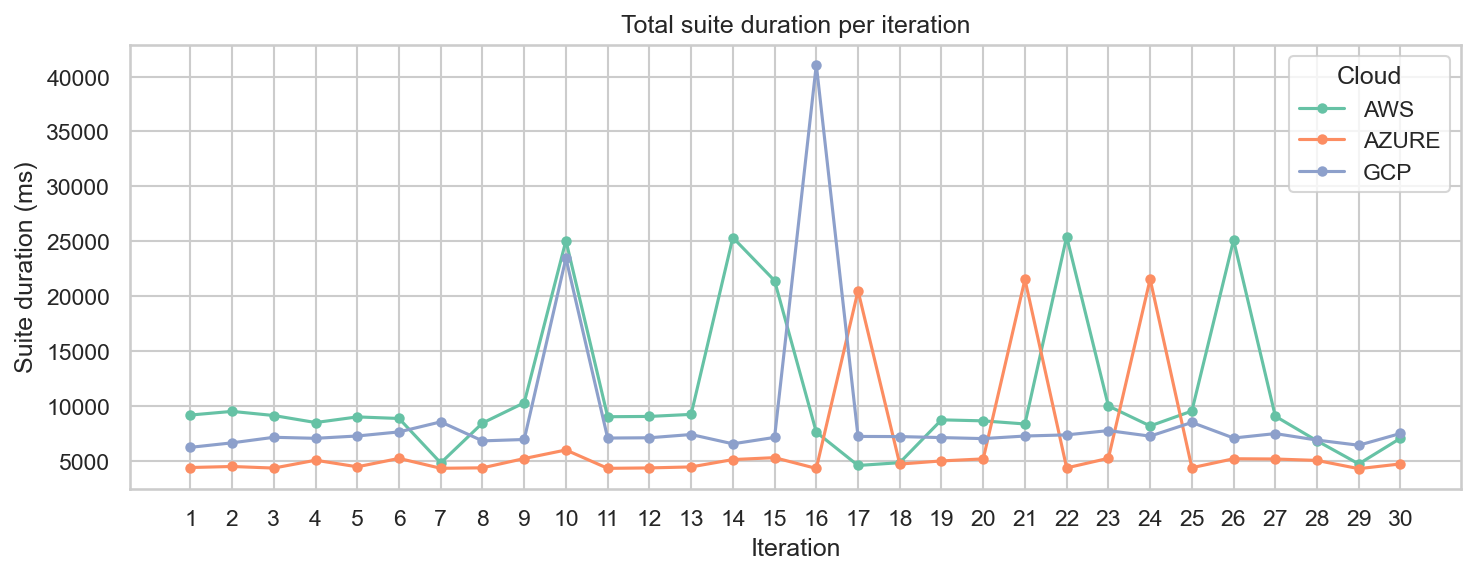

In [59]:
suite = (
    df.groupby(['cloud', 'iteration'])['testDuration']
    .sum()
    .reset_index()
    .rename(columns={'testDuration': 'suiteDuration'})
)

fig, ax = plt.subplots(figsize=(10, 4))
palette = {'aws': '#66c2a5', 'azure': '#fc8d62', 'gcp': '#8da0cb'}
for cloud, grp in suite.groupby('cloud', observed=True):
    grp = grp.sort_values('iteration')
    ax.plot(grp['iteration'], grp['suiteDuration'],
            marker='o', markersize=4, linewidth=1.5,
            label=cloud.upper(), color=palette[cloud])

ax.set_xlabel('Iteration')
ax.set_ylabel('Suite duration (ms)')
ax.set_title('Total suite duration per iteration')
ax.set_xticks(range(1, 31))
ax.legend(title='Cloud')
fig.tight_layout()
fig.savefig(FIGURES / 'suite_duration_time_series.png', dpi=300)
plt.show()

# 4. Per-Test Mean Duration
Bar chart comparing mean test duration per cloud for each individual test scenario. Makes it easy to spot which tests drive the overall performance differences between EKS, AKS, and GKE.

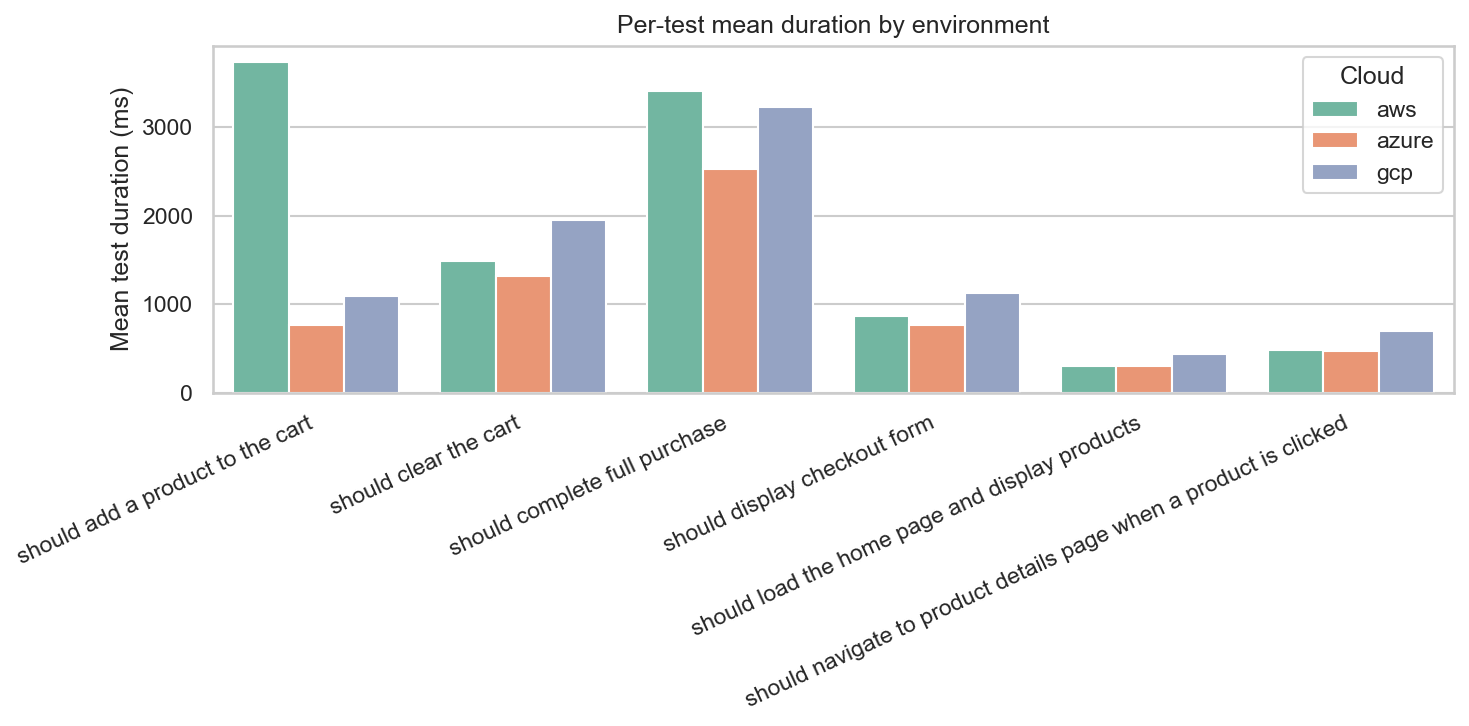

In [60]:
test_means = (
    df.groupby(['cloud', 'testName'])['testDuration']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=test_means, x='testName', y='testDuration',
            hue='cloud', palette='Set2', ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Mean test duration (ms)')
ax.set_title('Per-test mean duration by environment')
plt.setp(ax.get_xticklabels(), rotation=25, ha='right')
ax.legend(title='Cloud')
fig.tight_layout()
fig.savefig(FIGURES / 'per_test_timing_bar.png', dpi=300)
plt.show()

# 5. One-Way ANOVA
Tests whether cloud provider has a statistically significant effect on each performance metric. A p-value < 0.05 indicates the means differ more than expected by chance; those metrics are carried forward to post-hoc analysis.

## 4.1. ANOVA Assumption Checks
One-way ANOVA requires (a) approximate normality within each group and (b) equal variances.  
- **Shapiro-Wilk** tests per-cloud normality (p < 0.05 → reject normality).  
- **Levene's test** checks variance equality across clouds (p < 0.05 → unequal variances).  
- **Kruskal-Wallis** is the non-parametric alternative; agreement with ANOVA strengthens conclusions.

In [61]:
from scipy.stats import shapiro, levene, kruskal

check_targets = {'suiteDuration': suite} | {m: df[['cloud', m]] for m in PERF_METRICS}
cloud_names = ['aws', 'azure', 'gcp']

assumption_rows = []
for label, data in check_targets.items():
    col = 'suiteDuration' if label == 'suiteDuration' else label
    groups = [g[col].dropna().values for _, g in data.groupby('cloud')]
    all_vals = np.concatenate(groups)
    if all_vals.std() == 0:
        continue  # skip zero-variance metrics (already flagged in ANOVA cell)

    sw_ps = {name: round(shapiro(grp)[1], 4) if len(grp) >= 3 else np.nan
             for name, grp in zip(cloud_names, groups)}
    all_normal = all(p > 0.05 for p in sw_ps.values() if not np.isnan(p))

    _, p_lev = levene(*groups)
    h_kw, p_kw = kruskal(*groups)

    assumption_rows.append({
        'metric':        label,
        'SW aws':        sw_ps['aws'],
        'SW azure':      sw_ps['azure'],
        'SW gcp':        sw_ps['gcp'],
        'normal':        all_normal,
        'Levene p':      round(p_lev, 4),
        'equal var':     p_lev > 0.05,
        'KW H':          round(h_kw, 3),
        'KW p':          round(p_kw, 4),
        'KW sig':        p_kw < 0.05,
    })

assump_df = pd.DataFrame(assumption_rows).set_index('metric')
display(assump_df)

n_normal   = assump_df['normal'].sum()
n_eqvar    = assump_df['equal var'].sum()
n_agree    = (assump_df['KW sig'] == (assump_df['KW p'] < 0.05)).sum()
print(f"\nNormality satisfied: {n_normal}/{len(assump_df)} metrics")
print(f"Equal variances:     {n_eqvar}/{len(assump_df)} metrics")
print(f"ANOVA/KW agreement:  {n_agree}/{len(assump_df)} metrics")

,SW aws,SW azure,SW gcp,normal,Levene p,equal var,KW H,KW p,KW sig
metric,,,,,,,,,
suiteDuration,0.0000,0.0,0.0000,False,0.4772,True,38.822,0.0000,True
testDuration,0.0000,0.0,0.0000,False,0.0094,False,34.243,0.0000,True
ttfb,0.0000,0.0,0.0000,False,0.0000,False,279.227,0.0000,True
domInteractive,0.0000,0.0,0.0000,False,0.0007,False,62.600,0.0000,True
domContentLoaded,0.0000,0.0,0.0000,False,0.0007,False,64.147,0.0000,True
loadComplete,0.0000,0.0,0.0000,False,0.0063,False,65.203,0.0000,True
fcp,0.0000,0.0,0.0000,False,0.6744,True,74.262,0.0000,True
lcp,0.0000,0.0,0.0000,False,0.0267,False,68.451,0.0000,True
cls,0.0000,0.0,0.0000,False,0.6833,True,0.076,0.9625,False



Normality satisfied: 0/10 metrics
Equal variances:     3/10 metrics
ANOVA/KW agreement:  10/10 metrics


In [62]:
anova_targets = {'suiteDuration': suite} | {
    m: df[['cloud', m]] for m in PERF_METRICS
}

zero_variance, anova_results = [], []
for label, data in anova_targets.items():
    col = 'suiteDuration' if label == 'suiteDuration' else label
    all_vals = data[col].dropna()
    if all_vals.std() == 0:
        zero_variance.append({'metric': label, 'constant_value': all_vals.iloc[0]})
        continue
    groups = [g[col].dropna().values for _, g in data.groupby('cloud')]
    f, p = stats.f_oneway(*groups)
    anova_results.append({'metric': label, 'F': round(f, 3), 'p': round(p, 4),
                          'significant': p < 0.05})

if zero_variance:
    print("Excluded from ANOVA — zero variance across all clouds:")
    for r in zero_variance:
        print(f"  {r['metric']}: uniformly {r['constant_value']} in every record "
              f"→ no inter-cloud difference possible by definition")
    print()

anova_df = pd.DataFrame(anova_results).set_index('metric')
anova_df

Excluded from ANOVA — zero variance across all clouds:
  tbt: uniformly 0 in every record → no inter-cloud difference possible by definition



,F,p,significant
metric,,,
suiteDuration,3.945,0.0229,True
testDuration,4.433,0.0123,True
ttfb,210.695,0.0000,True
domInteractive,24.244,0.0000,True
domContentLoaded,24.672,0.0000,True
loadComplete,16.175,0.0000,True
fcp,26.563,0.0000,True
lcp,18.329,0.0000,True
cls,0.381,0.6833,False


# 6. Tukey HSD Post-hoc Test
For every metric that ANOVA flagged as significant, Tukey's Honestly Significant Difference test identifies *which* cloud pairs differ. Controls the family-wise error rate at 5%.

In [63]:
sig_metrics = anova_df[anova_df['significant']].index.tolist()
print('Significant metrics:', sig_metrics)

for label in sig_metrics:
    if label == 'suiteDuration':
        data, col = suite, 'suiteDuration'
    else:
        data, col = df[['cloud', label]], label
    sub = data[['cloud', col]].dropna()
    tukey = pairwise_tukeyhsd(sub[col], sub['cloud'])
    print(f'\n--- {label} ---')
    print(tukey)

Significant metrics: ['suiteDuration', 'testDuration', 'ttfb', 'domInteractive', 'domContentLoaded', 'loadComplete', 'fcp', 'lcp', 'inp']

--- suiteDuration ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2 meandiff p-adj    lower      upper   reject
---------------------------------------------------------
   aws  azure  -4433.4  0.017 -8204.2194 -662.5806   True
   aws    gcp  -1976.7 0.4273 -5747.5194 1794.1194  False
 azure    gcp   2456.7 0.2714 -1314.1194 6227.5194  False
---------------------------------------------------------

--- testDuration ---
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
   aws  azure -707.5777 0.0088 -1267.7033 -147.452   True
   aws    gcp   -304.84 0.4076  -864.9656 255.2857  False
 azure    gcp  402.7377 0.2118   -158.908 964.3834  False
---------------------------------------------------------

--- 

# 7. Cohen's d Effect Sizes
Quantifies the practical magnitude of each significant pairwise difference. Cohen's d < 0.2 is negligible, 0.2–0.5 small, 0.5–0.8 medium, > 0.8 large.

In [64]:
def cohens_d(a, b):
    pooled_std = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled_std if pooled_std else np.nan

pairs = [('aws', 'azure'), ('aws', 'gcp'), ('azure', 'gcp')]
effect_sizes = []

for label in sig_metrics:
    if label == 'suiteDuration':
        data, col = suite, 'suiteDuration'
    else:
        data, col = df[['cloud', label]], label
    grp = data.groupby('cloud')[col]
    for a, b in pairs:
        d = cohens_d(grp.get_group(a).dropna(), grp.get_group(b).dropna())
        effect_sizes.append({'metric': label, 'pair': f'{a} vs {b}',
                             "Cohen's d": round(d, 3)})

pd.DataFrame(effect_sizes).set_index(['metric', 'pair'])

Cohen's d
metric           pair                   
suiteDuration    aws vs azure      0.769
                 aws vs gcp        0.299
                 azure vs gcp     -0.411
testDuration     aws vs azure      0.296
                 aws vs gcp        0.126
                 azure vs gcp     -0.199
ttfb             aws vs azure     -1.535
                 aws vs gcp        0.264
                 azure vs gcp      1.718
domInteractive   aws vs azure      0.097
                 aws vs gcp       -0.525
                 azure vs gcp     -0.660
domContentLoaded aws vs azure      0.100
                 aws vs gcp       -0.529
                 azure vs gcp     -0.666
loadComplete     aws vs azure      0.085
                 aws vs gcp       -0.424
                 azure vs gcp     -0.559
fcp              aws vs azure     -0.016
                 aws vs gcp       -0.669
                 azure vs gcp     -0.740
lcp              aws vs azure      0.083
                 aws vs gcp       -0.484
                 azure vs gcp     -0.633
inp              aws vs azure      0.448
                 aws vs gcp       -0.715
                 azure vs gcp     -1.134

## 7.1. Navigation Timing Breakdown
Breaks the browser's Navigation Timing API into its constituent phases (DNS lookup, TCP connect, TLS handshake, server processing, content download). Identifies *where* in the request lifecycle cloud differences originate.

dnsLookup              tcpConnect              tlsHandshake              \
           mean median   std       mean median   std         mean median  std   
cloud                                                                           
aws         0.2    0.0  0.79       0.28    0.0  0.68          0.0    0.0  0.0   
azure       0.0    0.0  0.00       2.34    0.0  6.06          0.0    0.0  0.0   
gcp         0.0    0.0  0.01       0.26    0.0  0.68          0.0    0.0  0.0   

      serverProcessing              contentDownload               
                  mean median   std            mean median   std  
cloud                                                             
aws              14.48   13.2  5.61            1.04    0.7  1.06  
azure            25.86   23.8  8.15            1.86    1.5  0.99  
gcp              12.48   11.1  4.83            2.14    0.9  2.74

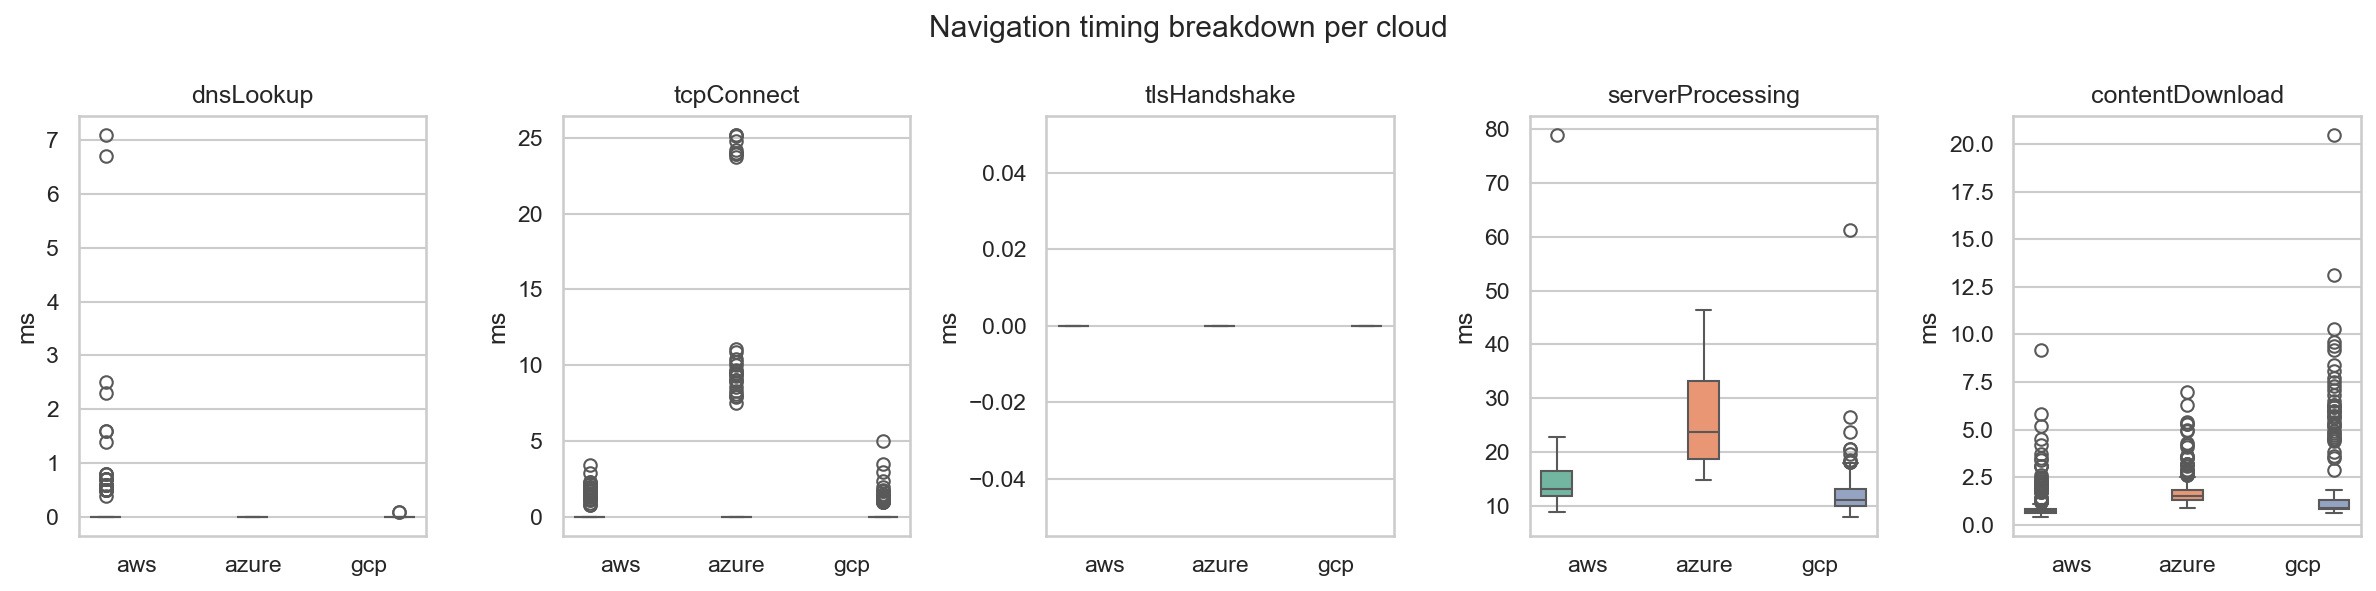

,F,p,significant
metric,,,
dnsLookup,11.636,0.0,True
tcpConnect,21.028,0.0,True
tlsHandshake,NaN,NaN,False
serverProcessing,236.262,0.0,True
contentDownload,18.804,0.0,True



--- Tukey HSD: dnsLookup ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   aws  azure     -0.2 0.0001 -0.3123 -0.0877   True
   aws    gcp  -0.1989 0.0001 -0.3112 -0.0866   True
 azure    gcp   0.0011 0.9997 -0.1115  0.1137  False
----------------------------------------------------

--- Tukey HSD: tcpConnect ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   aws  azure   2.0632    0.0   1.197  2.9293   True
   aws    gcp   -0.021 0.9982 -0.8871  0.8452  False
 azure    gcp  -2.0842    0.0 -2.9527 -1.2156   True
----------------------------------------------------

--- Tukey HSD: serverProcessing ---
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
--------------------------------------------------

Cohen's d
metric           pair                   
dnsLookup        aws vs azure      0.358
                 aws vs gcp        0.356
                 azure vs gcp     -0.148
tcpConnect       aws vs azure     -0.479
                 aws vs gcp        0.031
                 azure vs gcp      0.484
serverProcessing aws vs azure     -1.627
                 aws vs gcp        0.381
                 azure vs gcp      1.997
contentDownload  aws vs azure     -0.798
                 aws vs gcp       -0.529
                 azure vs gcp     -0.136

In [65]:
# dnsLookup / tcpConnect / tlsHandshake are 0 for reused connections
# serverProcessing and contentDownload are the most cloud-differentiating sub-components

nav_desc = (
    df.groupby('cloud')[NAV_METRICS]
    .agg(['mean', 'median', 'std'])
    .round(2)
)
display(nav_desc)

fig, axes = plt.subplots(1, len(NAV_METRICS), figsize=(16, 4))
for ax, col in zip(axes, NAV_METRICS):
    sns.boxplot(data=df, x='cloud', y=col, hue='cloud',
                legend=False, palette='Set2', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('ms')

fig.suptitle('Navigation timing breakdown per cloud')
fig.tight_layout()
fig.savefig(FIGURES / 'nav_timing_breakdown.png', dpi=300)
plt.show()

# ANOVA + Tukey + Cohen's d on nav metrics
nav_anova = []
for col in NAV_METRICS:
    groups = [g[col].dropna().values for _, g in df.groupby('cloud')]
    f, p = stats.f_oneway(*groups)
    nav_anova.append({'metric': col, 'F': round(f, 3), 'p': round(p, 4), 'significant': p < 0.05})

nav_anova_df = pd.DataFrame(nav_anova).set_index('metric')
display(nav_anova_df)

nav_sig = nav_anova_df[nav_anova_df['significant']].index.tolist()
for col in nav_sig:
    sub = df[['cloud', col]].dropna()
    tukey = pairwise_tukeyhsd(sub[col], sub['cloud'])
    print(f'\n--- Tukey HSD: {col} ---')
    print(tukey)

nav_effects = []
for col in nav_sig:
    grp = df.groupby('cloud')[col]
    for a, b in [('aws', 'azure'), ('aws', 'gcp'), ('azure', 'gcp')]:
        d = cohens_d(grp.get_group(a).dropna(), grp.get_group(b).dropna())
        nav_effects.append({'metric': col, 'pair': f'{a} vs {b}', "Cohen's d": round(d, 3)})

if nav_effects:
    print("\n=== Cohen's d ===")
    display(pd.DataFrame(nav_effects).set_index(['metric', 'pair']))

## 7.2. RTT Decomposition — Stacked Bar
Shows the mean contribution of each request-lifecycle phase to total client-side latency per cloud. Zeros for DNS/TCP/TLS reflect connection reuse (cached DNS, keep-alive TCP) — a browser behaviour, not missing data. `serverProcessing` is the cloud-controlled component.

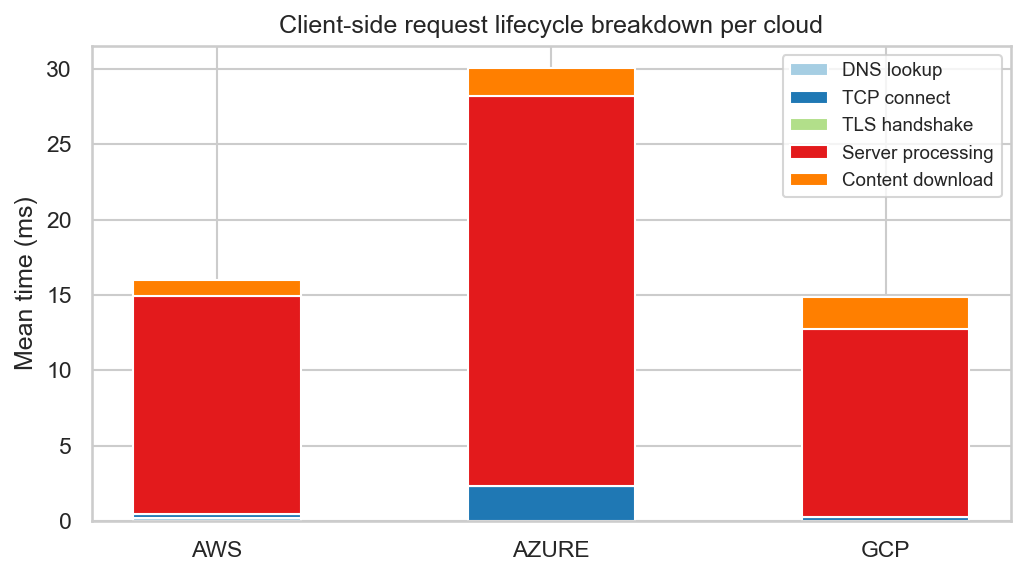


Mean breakdown per cloud (ms):


,dnsLookup,tcpConnect,tlsHandshake,serverProcessing,contentDownload
cloud,,,,,
aws,0.2,0.28,0.0,14.48,1.04
azure,0.0,2.34,0.0,25.86,1.86
gcp,0.0,0.26,0.0,12.48,2.14


In [66]:
phase_colors = {
    'dnsLookup':        '#a6cee3',
    'tcpConnect':       '#1f78b4',
    'tlsHandshake':     '#b2df8a',
    'serverProcessing': '#e31a1c',
    'contentDownload':  '#ff7f00',
}
phase_labels = {
    'dnsLookup':        'DNS lookup',
    'tcpConnect':       'TCP connect',
    'tlsHandshake':     'TLS handshake',
    'serverProcessing': 'Server processing',
    'contentDownload':  'Content download',
}

means = df.groupby('cloud')[NAV_METRICS].mean()

fig, ax = plt.subplots(figsize=(7, 4))
clouds = ['aws', 'azure', 'gcp']
x = np.arange(len(clouds))
width = 0.5
bottom = np.zeros(len(clouds))

for col in NAV_METRICS:
    vals = [means.loc[c, col] for c in clouds]
    ax.bar(x, vals, width, bottom=bottom,
           label=phase_labels[col], color=phase_colors[col], edgecolor='white')
    bottom += np.array(vals)

ax.set_xticks(x)
ax.set_xticklabels([c.upper() for c in clouds])
ax.set_ylabel('Mean time (ms)')
ax.set_title('Client-side request lifecycle breakdown per cloud')
ax.legend(loc='upper right', fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / 'rtt_decomposition_stacked.png', dpi=300)
plt.show()

print("\nMean breakdown per cloud (ms):")
display(means[NAV_METRICS].round(2))

# 8. Cost Analysis
Loads billing data from `costs.csv` and cross-references it with iteration counts and mean suite durations. Computes cost per iteration and iterations per dollar to compare cloud value-for-money.

In [67]:
costs = pd.read_csv(ROOT / 'data' / 'costs.csv')

# mean suite duration per cloud (all iterations)
mean_suite = suite.groupby('cloud')['suiteDuration'].mean().reset_index()
mean_suite.columns = ['cloud', 'mean_suite_ms']

cost_tbl = costs.merge(mean_suite, on='cloud')
cost_tbl['cost_per_iteration_usd'] = (
    cost_tbl['cost_total_usd'] / cost_tbl['iterations']
).round(4)

# efficiency = iterations completed per dollar
cost_tbl['iterations_per_dollar'] = (
    cost_tbl['iterations'] / cost_tbl['cost_total_usd']
).round(1)

cost_tbl[['cloud', 'environment', 'iterations', 'cost_total_usd',
           'cost_per_iteration_usd', 'iterations_per_dollar', 'mean_suite_ms']]

,cloud,environment,iterations,cost_total_usd,cost_per_iteration_usd,iterations_per_dollar,mean_suite_ms
0,aws,eks,30,0.9182,0.0306,32.7,10838.8
1,azure,aks,30,1.4631,0.0488,20.5,6405.4
2,gcp,gke,30,0.7422,0.0247,40.4,8862.1


# 9. Runner Timings & Network RTT
Line plots (mean ± 1 SD shaded band) for dependency install time, network TTFB, and total RTT per iteration. Shows iteration-to-iteration variability in the CI runner environment itself, separate from application-level metrics.

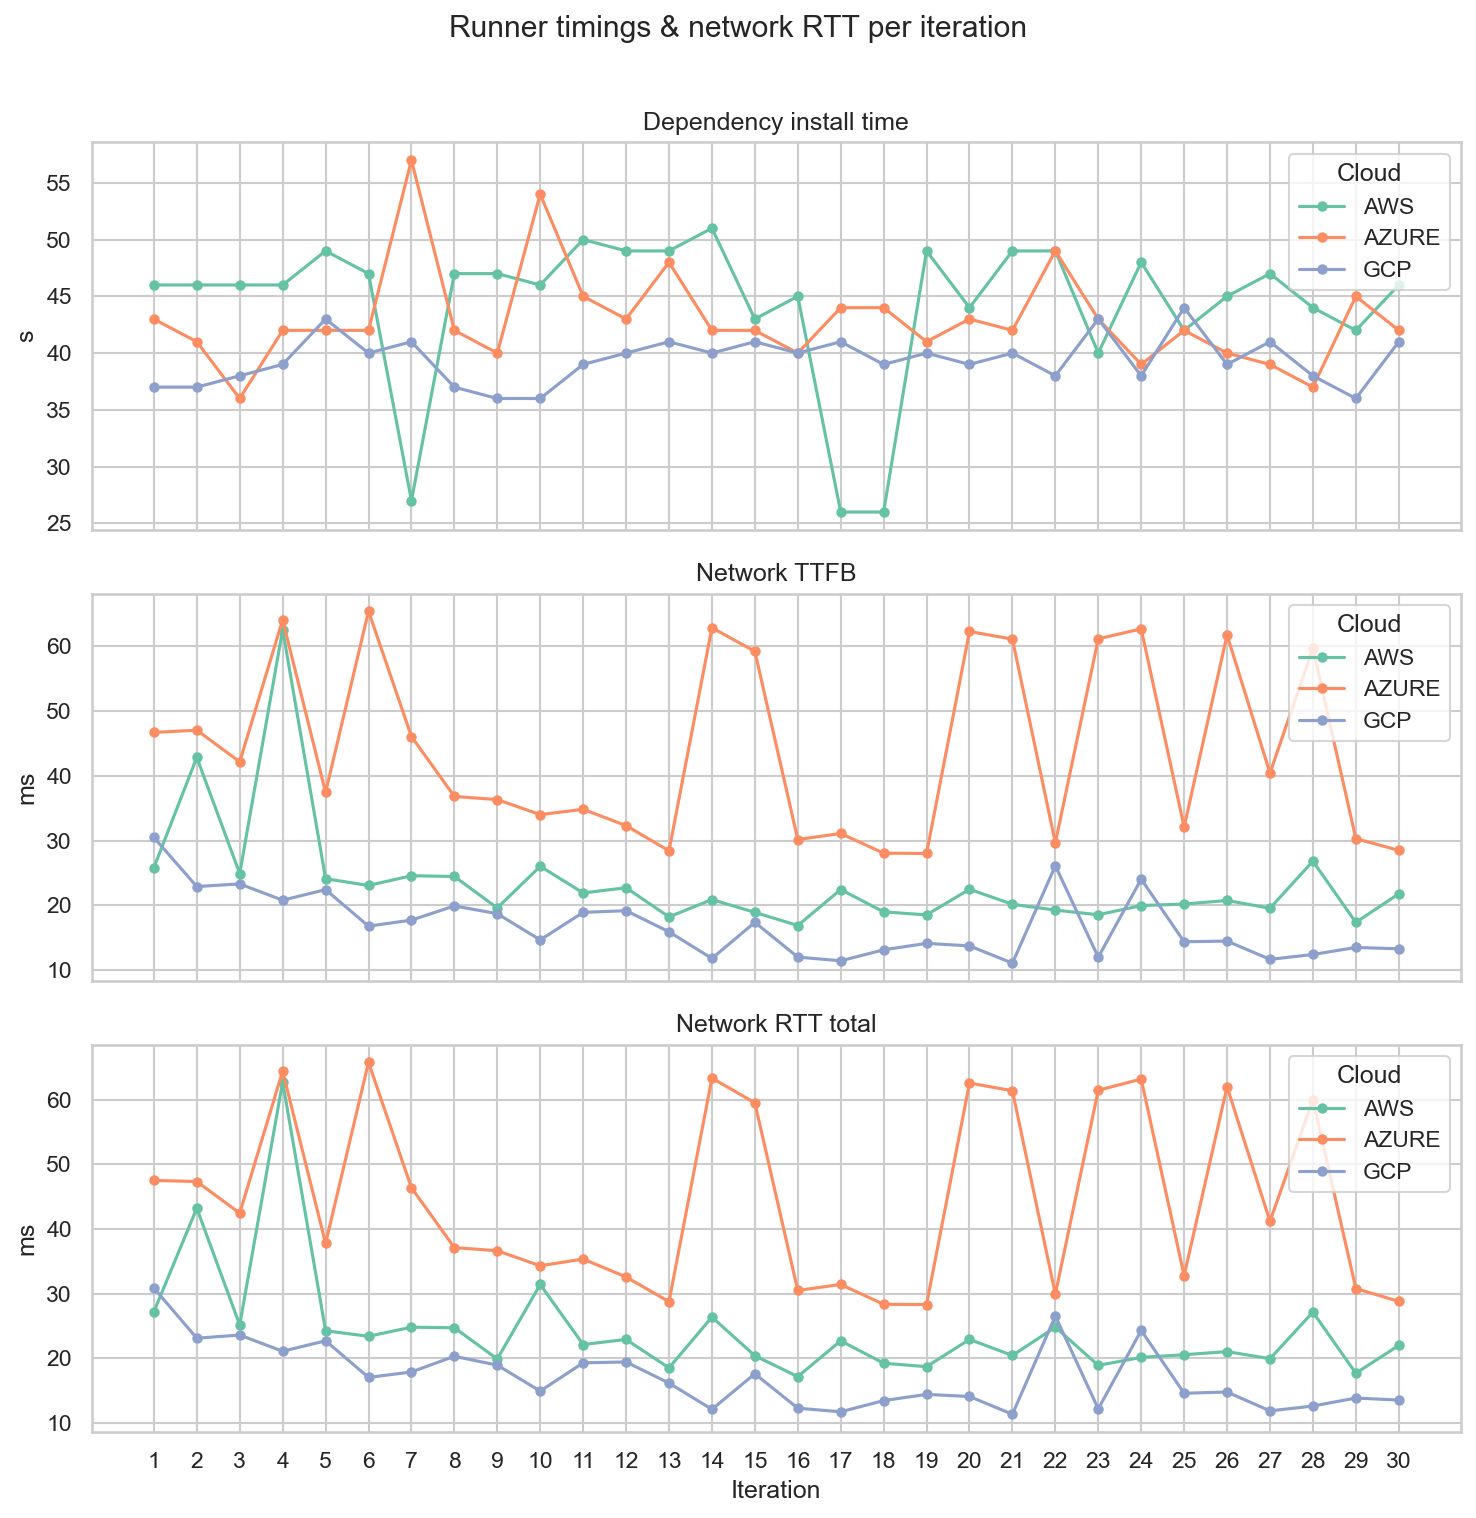

In [68]:
palette = {'aws': '#66c2a5', 'azure': '#fc8d62', 'gcp': '#8da0cb'}
metrics = [
    ('installSeconds', 'Dependency install time', 's'),
    ('rtt_ttfb_ms',    'Network TTFB',            'ms'),
    ('rtt_total_ms',   'Network RTT total',        'ms'),
]

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

for ax, (col, title, unit) in zip(axes, metrics):
    for cloud, grp in runner_df.groupby('cloud', observed=True):
        grp = grp.sort_values('iteration')
        mean = grp.groupby('iteration')[col].mean()
        std  = grp.groupby('iteration')[col].std()
        iters = mean.index
        ax.plot(iters, mean, marker='o', markersize=4, linewidth=1.5,
                label=cloud.upper(), color=palette[cloud])
        ax.fill_between(iters, mean - std, mean + std,
                        alpha=0.15, color=palette[cloud])
    ax.set_title(title)
    ax.set_ylabel(unit)
    ax.legend(title='Cloud')

axes[-1].set_xlabel('Iteration')
axes[-1].set_xticks(range(1, 31))
fig.suptitle('Runner timings & network RTT per iteration', y=1.01)
fig.tight_layout()
fig.savefig(FIGURES / 'runner_network_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

## 9.1. Dependency Install Time per Iteration
Line chart showing how long `npm install` (or equivalent) took in each iteration per cloud. A separate view from the combined RTT plot above, useful for spotting whether package-registry or network conditions caused install-time spikes on individual runs.

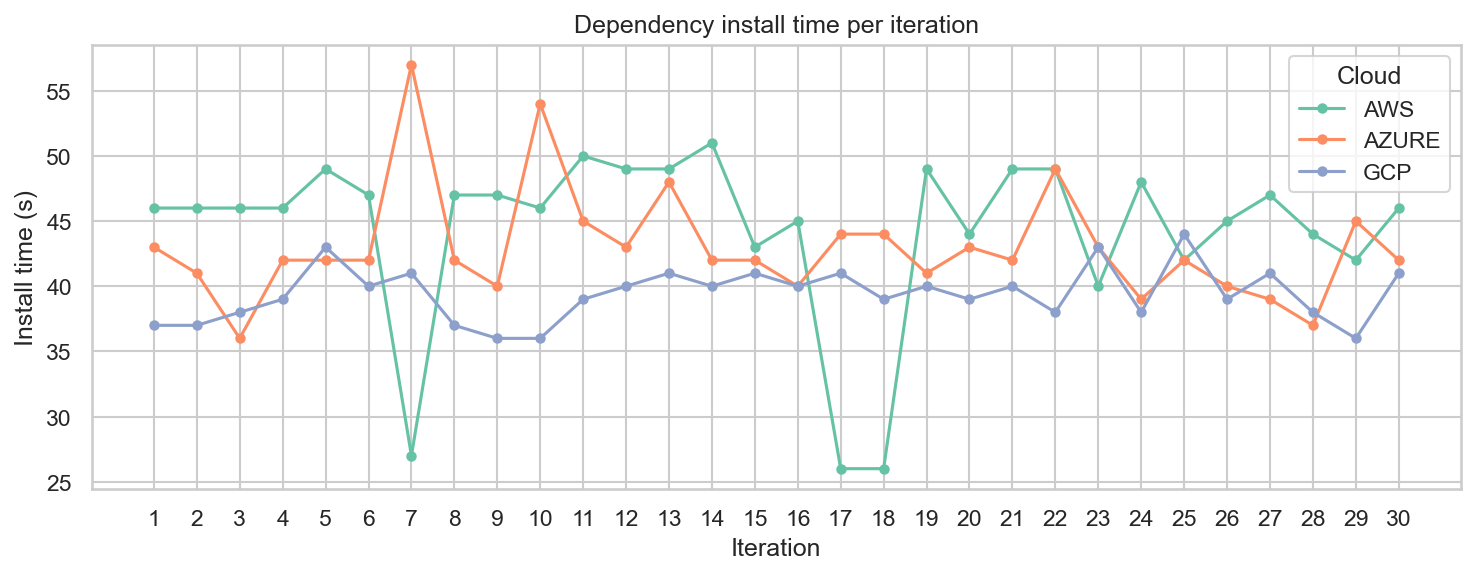

In [69]:
fig, ax = plt.subplots(figsize=(10, 4))

palette = {'aws': '#66c2a5', 'azure': '#fc8d62', 'gcp': '#8da0cb'}
for cloud, grp in runner_df.groupby('cloud', observed=True):
    grp = grp.sort_values('iteration')
    ax.plot(grp['iteration'], grp['installSeconds'],
            marker='o', markersize=4, linewidth=1.5,
            label=cloud.upper(), color=palette[cloud])

ax.set_xlabel('Iteration')
ax.set_ylabel('Install time (s)')
ax.set_title('Dependency install time per iteration')
ax.set_xticks(range(1, 31))
ax.legend(title='Cloud')
fig.tight_layout()
fig.savefig(FIGURES / 'install_time_series.png', dpi=300)
plt.show()

## 9.2. Statistical Tests — Runner Timings & Network RTT
Applies the same ANOVA → Tukey HSD → Cohen's d pipeline to runner-level metrics (install time, test execution time, DNS, TCP, TTFB, total RTT) to determine whether infrastructure-layer differences between clouds are statistically significant.

## 9.2. CI Runner — Queue vs Execution Time
Breaks total CI wall-clock time into queueing (waiting for an agent) and execution (active work). Sourced from `provider_timings.json` written by each cloud's run script.

runnerQueueSeconds       runnerExecutionSeconds       
                    mean   std                   mean    std
cloud                                                       
aws                 0.57  0.50                 126.70  34.05
azure               8.27  0.87                  78.07   9.17
gcp                 1.03  0.18                 121.60  17.27

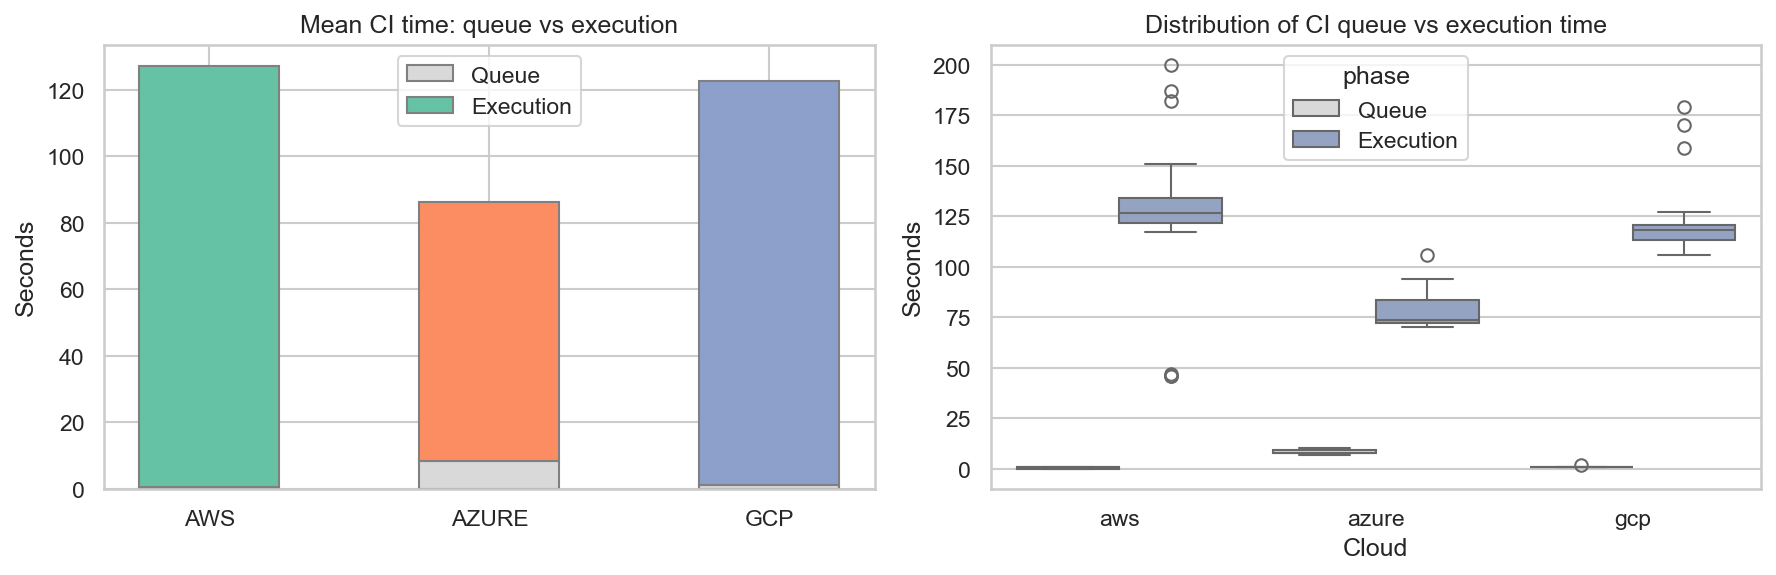

In [70]:
ci_summary = (
    runner_df.groupby('cloud')[['runnerQueueSeconds', 'runnerExecutionSeconds']]
    .agg(['mean', 'std'])
    .round(2)
)
display(ci_summary)

# Stacked bar: mean queue + mean execution per cloud
ci_means = runner_df.groupby('cloud')[['runnerQueueSeconds', 'runnerExecutionSeconds']].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette = {'aws': '#66c2a5', 'azure': '#fc8d62', 'gcp': '#8da0cb'}
clouds = ['aws', 'azure', 'gcp']
x = np.arange(len(clouds))
width = 0.5

ax = axes[0]
queue_vals = [ci_means.loc[c, 'runnerQueueSeconds'] for c in clouds]
exec_vals  = [ci_means.loc[c, 'runnerExecutionSeconds'] for c in clouds]
bars_q = ax.bar(x, queue_vals, width, label='Queue', color='#d9d9d9', edgecolor='grey')
bars_e = ax.bar(x, exec_vals,  width, bottom=queue_vals, label='Execution',
                color=[palette[c] for c in clouds], edgecolor='grey')
ax.set_xticks(x)
ax.set_xticklabels([c.upper() for c in clouds])
ax.set_ylabel('Seconds')
ax.set_title('Mean CI time: queue vs execution')
ax.legend()

# Box plots of queue and execution separately
ax2 = axes[1]
data_plot = runner_df[['cloud', 'runnerQueueSeconds', 'runnerExecutionSeconds']].melt(
    id_vars='cloud', var_name='phase', value_name='seconds'
)
data_plot['phase'] = data_plot['phase'].map({
    'runnerQueueSeconds': 'Queue', 'runnerExecutionSeconds': 'Execution'
})
sns.boxplot(data=data_plot, x='cloud', y='seconds', hue='phase',
            palette={'Queue': '#d9d9d9', 'Execution': '#8da0cb'}, ax=ax2)
ax2.set_xlabel('Cloud')
ax2.set_ylabel('Seconds')
ax2.set_title('Distribution of CI queue vs execution time')

fig.tight_layout()
fig.savefig(FIGURES / 'ci_queue_vs_execution.png', dpi=300)
plt.show()

In [71]:
RTT_COLS = ['runnerQueueSeconds', 'runnerExecutionSeconds',
            'installSeconds', 'testSeconds',
            'dns_ms', 'tcp_ms', 'rtt_ttfb_ms', 'rtt_total_ms']

rtt_anova = []
for col in RTT_COLS:
    groups = [g[col].dropna().values for _, g in runner_df.groupby('cloud')]
    f, p = stats.f_oneway(*groups)
    rtt_anova.append({'metric': col, 'F': round(f, 3), 'p': round(p, 4), 'significant': p < 0.05})

rtt_anova_df = pd.DataFrame(rtt_anova).set_index('metric')
print('=== ANOVA ===')
display(rtt_anova_df)

rtt_sig = rtt_anova_df[rtt_anova_df['significant']].index.tolist()
print('\nSignificant metrics:', rtt_sig)

for col in rtt_sig:
    sub = runner_df[['cloud', col]].dropna()
    tukey = pairwise_tukeyhsd(sub[col], sub['cloud'])
    print(f'\n--- Tukey HSD: {col} ---')
    print(tukey)

rtt_effects = []
for col in rtt_sig:
    grp = runner_df.groupby('cloud')[col]
    for a, b in [('aws', 'azure'), ('aws', 'gcp'), ('azure', 'gcp')]:
        d = cohens_d(grp.get_group(a).dropna(), grp.get_group(b).dropna())
        rtt_effects.append({'metric': col, 'pair': f'{a} vs {b}', "Cohen's d": round(d, 3)})

print("\n=== Cohen's d ===")
display(pd.DataFrame(rtt_effects).set_index(['metric', 'pair']))

=== ANOVA ===


,F,p,significant
metric,,,
runnerQueueSeconds,1610.780,0.0000,True
runnerExecutionSeconds,41.708,0.0000,True
installSeconds,8.800,0.0003,True
testSeconds,4.188,0.0184,True
dns_ms,265.774,0.0000,True
tcp_ms,76.137,0.0000,True
rtt_ttfb_ms,60.324,0.0000,True
rtt_total_ms,59.846,0.0000,True



Significant metrics: ['runnerQueueSeconds', 'runnerExecutionSeconds', 'installSeconds', 'testSeconds', 'dns_ms', 'tcp_ms', 'rtt_ttfb_ms', 'rtt_total_ms']

--- Tukey HSD: runnerQueueSeconds ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
   aws  azure      7.7   0.0  7.3373  8.0627   True
   aws    gcp   0.4667 0.008  0.1039  0.8294   True
 azure    gcp  -7.2333   0.0 -7.5961 -6.8706   True
---------------------------------------------------

--- Tukey HSD: runnerExecutionSeconds ---
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
   aws  azure -48.6333    0.0 -62.5896 -34.6771   True
   aws    gcp     -5.1 0.6597 -19.0562   8.8562  False
 azure    gcp  43.5333    0.0  29.5771  57.4896   True
------------------------------------------------------

--- Tukey HSD

Cohen's d
metric                 pair                   
runnerQueueSeconds     aws vs azure    -10.846
                       aws vs gcp       -1.231
                       azure vs gcp     11.528
runnerExecutionSeconds aws vs azure      1.951
                       aws vs gcp        0.189
                       azure vs gcp     -3.149
installSeconds         aws vs azure      0.250
                       aws vs gcp        1.012
                       azure vs gcp      1.046
testSeconds            aws vs azure      0.770
                       aws vs gcp        0.200
                       azure vs gcp     -0.608
dns_ms                 aws vs azure      4.208
                       aws vs gcp        4.211
                       azure vs gcp      0.231
tcp_ms                 aws vs azure     -2.101
                       aws vs gcp        3.322
                       azure vs gcp      2.388
rtt_ttfb_ms            aws vs azure     -1.759
                       aws vs gcp        0.915
                       azure vs gcp      2.577
rtt_total_ms           aws vs azure     -1.715
                       aws vs gcp        0.994
                       azure vs gcp      2.586

# 10. Flakiness Heatmap
Calculates the flaky rate (proportion of iterations where a test needed at least one retry) for each test × cloud combination and renders it as a heatmap. Highlights which tests and environments are least reliable.

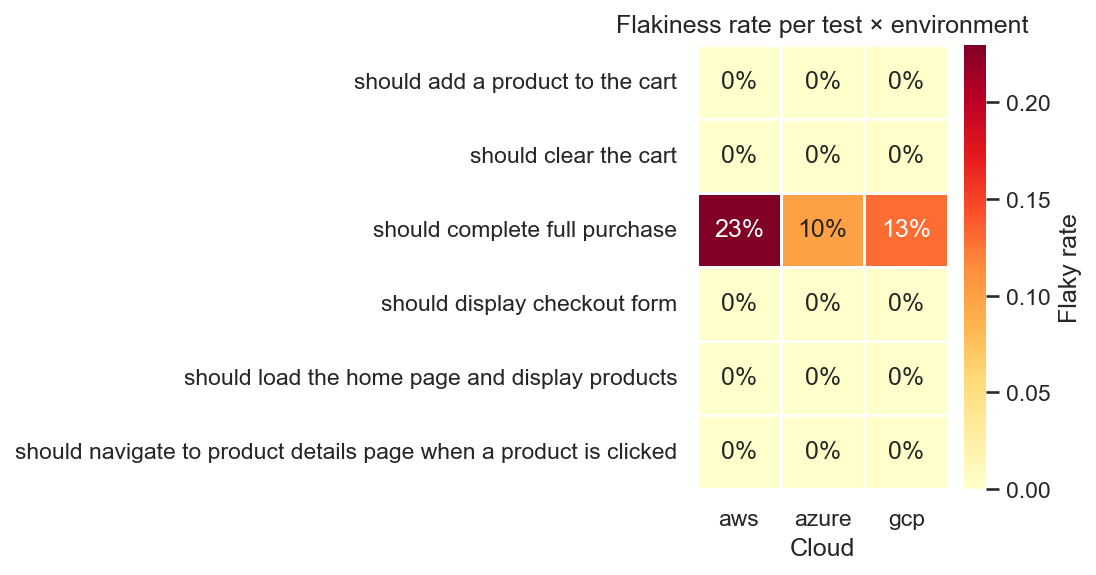

In [72]:
flakiness = []
for cloud, (env, run_dir) in CLOUDS.items():
    summary = json.loads((run_dir / 'summary.json').read_text())
    for t in summary['tests']:
        flakiness.append({'cloud': cloud, 'testName': t['testName'],
                          'flakyRate': t['flakyRate']})

flk_df = pd.DataFrame(flakiness)
flk_pivot = flk_df.pivot(index='testName', columns='cloud', values='flakyRate')

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(flk_pivot, annot=True, fmt='.0%', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Flaky rate'}, ax=ax)
ax.set_title('Flakiness rate per test × environment')
ax.set_xlabel('Cloud')
ax.set_ylabel('')
fig.tight_layout()
fig.savefig(FIGURES / 'flakiness_heatmap.png', dpi=300)
plt.show()

# 11. Export Figures
Lists all PNG figures saved to `data/figures/` at 300 dpi during the notebook run. Each section saves its own figure inline; this cell just confirms the full set of exports.

In [73]:
for f in sorted(FIGURES.glob('*.png')):
    print(f.name)

ci_queue_vs_execution.png
flakiness_heatmap.png
install_time_series.png
metric_boxplots.png
nav_timing_breakdown.png
per_test_timing_bar.png
rtt_decomposition_stacked.png
runner_network_metrics.png
suite_duration_boxplot.png
suite_duration_time_series.png
